In [1]:
pip install plotly


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd


In [3]:
import numpy as np

In [4]:
import plotly.express as px

In [5]:
import seaborn as sns

In [6]:
import matplotlib.pyplot as plt

In [10]:
df= pd.read_csv(r'D:\Data_science\Day_5\Data_sets\Titanic-Dataset.csv')

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
numerical_columns = df.select_dtypes(include=['number','int64','float64']).columns

In [15]:
df[numerical_columns].head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [17]:
categorical_columns = df.select_dtypes(include=['object','category']).columns

In [18]:
df[categorical_columns].head()

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


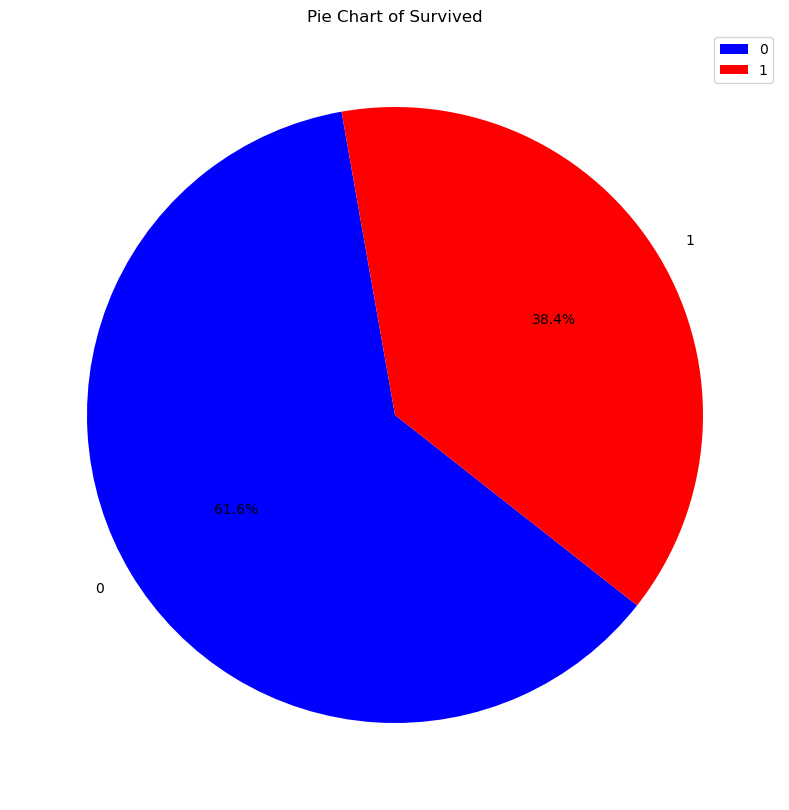

In [23]:
plt.figure(figsize=(15,10))
plt.pie(df['Survived'].value_counts(),labels=df['Survived'].value_counts().index, autopct='%0.001f%%', startangle=100,colors=['blue','red'])
plt.title('Pie Chart of Survived')
plt.legend()
plt.show()

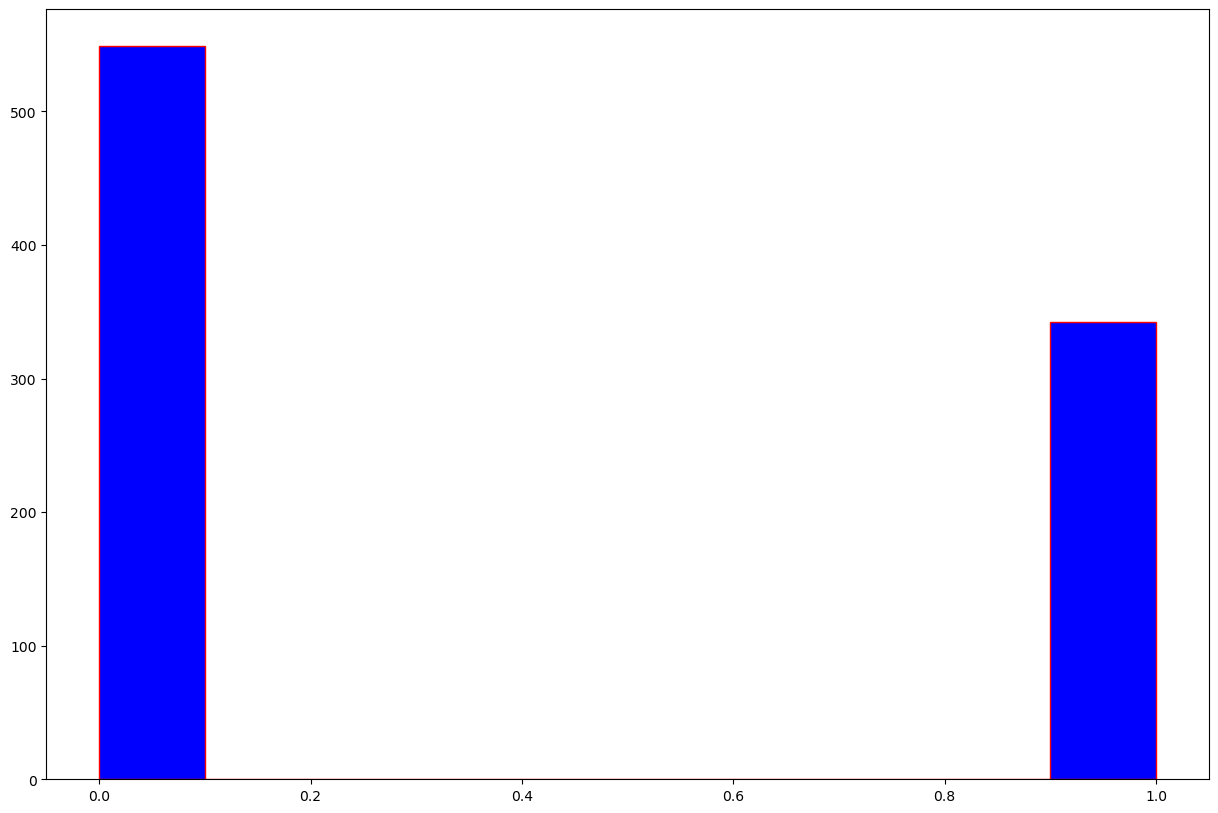

In [63]:
plt.figure(figsize=(15,10))
plt.hist(df['Survived'],color='blue',edgecolor='red')
plt.show()

In [64]:
df[df['Survived']==0].head() #dead people

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [65]:
df[df['Survived']==1].head() # survived people

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [92]:
#df[df['Survived']==0].value_counts().sort_index()

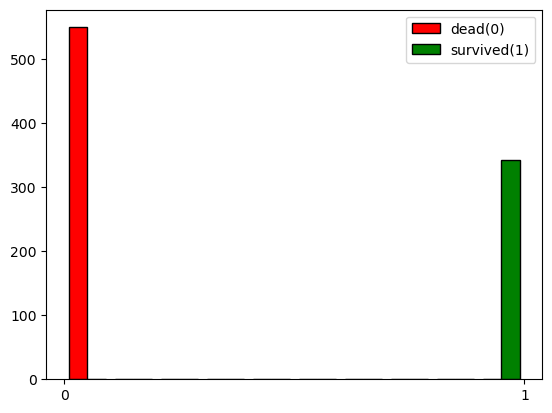

In [67]:
a = [df[df['Survived']==0]['Survived'],df[df['Survived']==1]['Survived']]
plt.hist(a,color=['red','green'],label=['dead(0)','survived(1)'],edgecolor='black')
plt.xticks([0,1])
plt.xticks(rotation=0)
plt.legend()
plt.show()


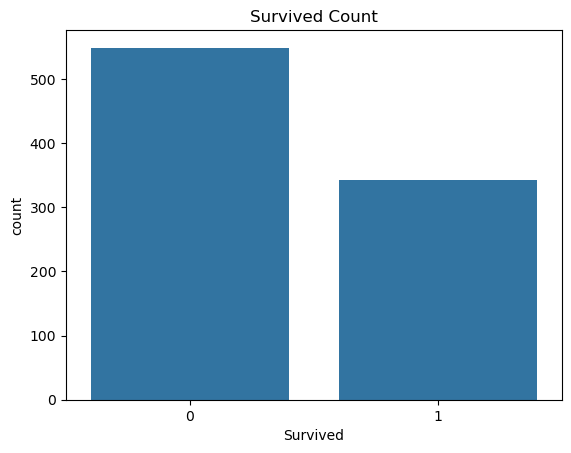

In [69]:
# Count Plot: Survived (0 = No , 1= Yes)
sns.countplot(data=df, x="Survived")
plt.title('Survived Count')
plt.show()

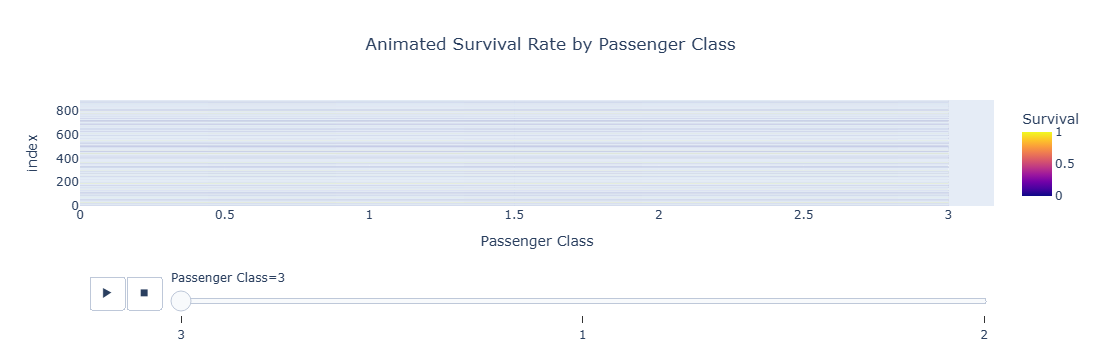

In [78]:
# set the style for seaborn
sns.set(style="whitegrid")

# 1. animinated barchart : survival rate by Pclass
fig_animated_class = px.bar(df, x='Pclass', color='Survived', barmode='group', animation_frame='Pclass',
                           labels={'Pclass': 'Passenger Class','Survived':'Survival'},
                           title="Animated Survival Rate by Passenger Class")
fig_animated_class.update_layout(title_x=0.5) #centered the title
fig_animated_class.show()


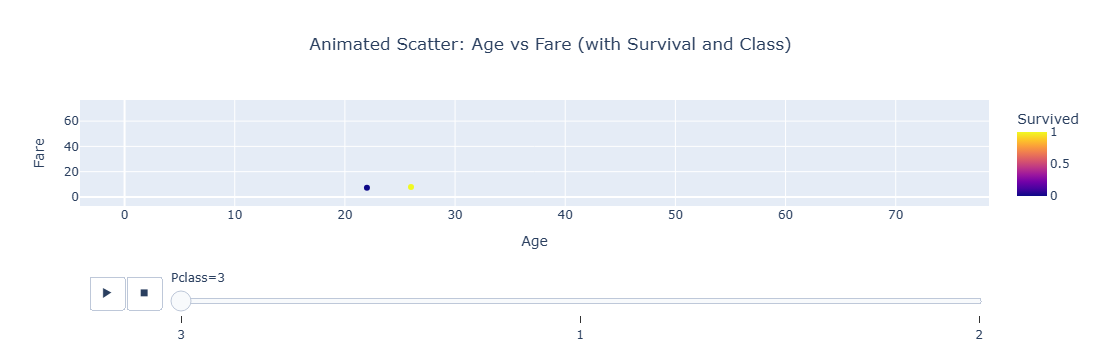

In [75]:
# 2. Animated scatter plot : age v fare with survival as color
fig_animated_scatter = px.scatter(df,x='Age', y='Fare', color='Survived',
                                 animation_frame='Pclass', animation_group='Survived',
                                 labels={'Age':'Age','Fare':'Fare'},
                                 title="Animated Scatter: Age vs Fare (with Survival and Class)")
fig_animated_scatter.update_layout(title_x=0.5) # center the title
fig_animated_scatter.show()

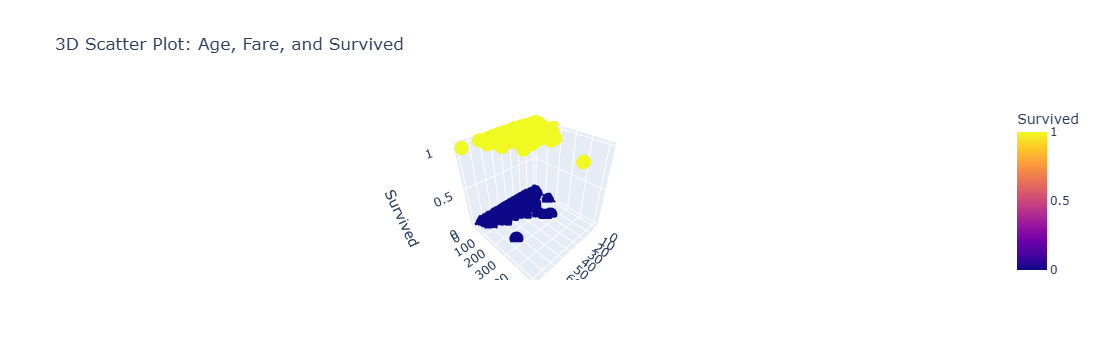

In [77]:
# 3. 3D scatter Plot: age,fare,
fig_3d = px.scatter_3d(df.dropna(subset=['Age','Fare']), x='Age', y='Fare', z='Survived', color='Survived',
                      labels={'Age':'Age','Fare':'Fare','Survived':'Survived'},
                      title="3D Scatter Plot: Age, Fare, and Survived")
fig_3d.show()

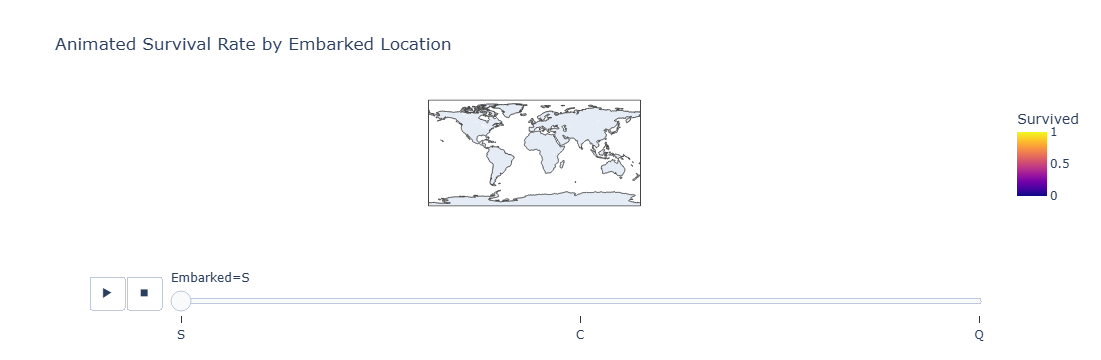

In [87]:
# 4. animated choropleth map : survived rate by embarked location(based on 'embarked')


embarked_location_map = {
    'C':'Cherbourg, France',
    'Q':'Queenstown, Ireland',
    'S':'Southampton, UK'
}

df['Embarked Location'] = df['Embarked'].map(embarked_location_map)

#NOte: Plotly chor0pleth map usually require geographical data
# here , we are shpwing an animated plot of survival by embarked location

fig_choropleth = px.choropleth(df, locations='Embarked Location', color='Survived', hover_name='Embarked Location',
                              animation_frame='Embarked', title="Animated Survival Rate by Embarked Location")
fig_choropleth.show()

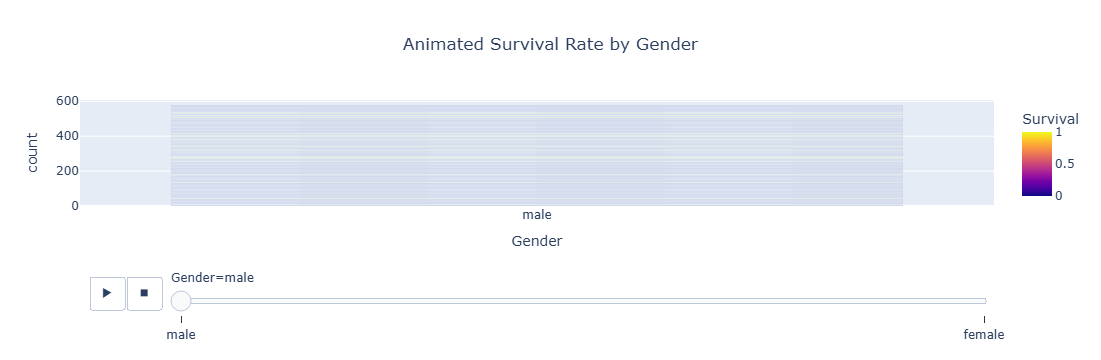

In [86]:
# 5. animated bar chart: survival rate by gender (instead of piechart)
fig_bar_gender = px.bar(df, x='Sex', color='Survived', barmode='group',animation_frame='Sex', 
                        labels={'Sex': 'Gender', 'Survived':'Survival'},
                        title="Animated Survival Rate by Gender")
fig_bar_gender.update_layout(title_x=0.5)
fig_bar_gender.show()

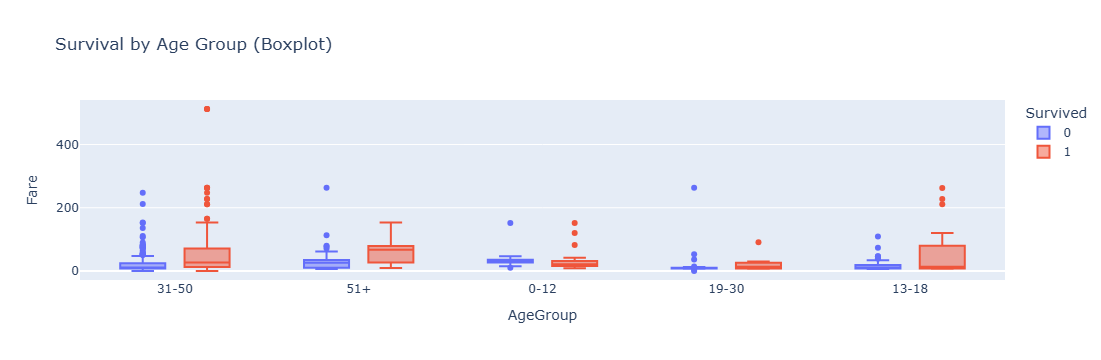

In [91]:
# 6. Survival by age group (Box plot)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 20, 50, 80],
                       labels=['0-12', '13-18', '19-30', '31-50', '51+'])

fig_box_age = px.box(df, x='AgeGroup', y='Fare', color='Survived',
                    title="Survival by Age Group (Boxplot)")
fig_box_age.show()

## Geo Pandas

In [93]:
! pip install geopandas

   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.2 MB 4.8 MB/s eta 0:00:04
   ------- -------------------------------- 3.4/19.2 MB 7.7 MB/s eta 0:00:03
   ------------ --------------------------- 6.0/19.2 MB 9.5 MB/s eta 0:00:02
   ------------------ --------------------- 8.7/19.2 MB 10.1 MB/s eta 0:00:02
   ----------------------- ---------------- 11.3/19.2 MB 10.7 MB/s eta 0:00:01
   ----------------------------- ---------- 14.2/19.2 MB 11.1 MB/s eta 0:00:01
   ----------------------------------- ---- 17.0/19.2 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------  19.1/19.2 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 19.2/19.2 MB 10.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------------------- ------------------- 3.1/6.3 MB 14.2 MB/s eta 0:00:01
   -------------------------------------- - 6.0/6.3 MB 14.2 MB/s eta 0:00:01
   